# EAUI 2026 — Análisis Avanzado Completo

MCA, Clustering, Clasificadores binario y multiclase

In [1]:
import pandas as pd
import numpy as np
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns
import prince
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix, silhouette_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('✓ Setup completado')

✓ Setup completado


In [2]:
# Cargar SPSS
df, meta = pyreadstat.read_sav('data/sav/2026.sav')
print(f'Dataset: {df.shape}')
rename_dict = {
    'ZONA': 'zona', 'COD_REGION': 'region',
    'A9': 'parentesco_jh', 'A10': 'educ_jh', 'A11': 'ocupacion_jh', 'A12_1': 'ingreso_hogar',
    'Q1_1': 'edad', 'Q1_2': 'sexo', 'Q1_3': 'educ', 'Q1_4': 'ocupacion_encuestado',
    'P1': 'acceso_internet_hogar', 'P2': 'n_smartphones_hogar', 'P2_1': 'n_computadores_hogar',
    'Q5': 'uso_computador', 'Q7': 'uso_smartphone',
    'FE_PERSONAS': 'fe_personas', 'FE_HOGAR': 'fe_hogar'
}
df.rename(columns=rename_dict, inplace=True)
df['acceso_internet_hogar'] = df['acceso_internet_hogar'].map({1:'Sí', 2:'No'})
print(f'acceso: {df["acceso_internet_hogar"].value_counts().to_dict()}')

Dataset: (5000, 587)
acceso: {'Sí': 4841, 'No': 159}


In [3]:
# Derivar nivel_habilidades
q8_cols = [col for col in df.columns if col.startswith('Q8_')]
print(f'Q8 cols: {len(q8_cols)}')
def calc_nivel(row):
    vals = [row[col] for col in q8_cols if pd.notna(row[col])]
    if not vals: return np.nan
    n_si = sum(1 for v in vals if v == 1)
    n_tot = len(vals)
    ratio = n_si / n_tot if n_tot > 0 else 0
    return 'Avanzado' if ratio >= 0.75 else ('Intermedio' if ratio >= 0.50 else ('Básico' if ratio >= 0.25 else 'Sin habilidades'))
df['nivel_habilidades'] = df.apply(calc_nivel, axis=1)
print(f'nivel: {df["nivel_habilidades"].value_counts().to_dict()}')

Q8 cols: 19


nivel: {'Sin habilidades': 1700, 'Básico': 1114, 'Intermedio': 984, 'Avanzado': 960}


In [4]:
# Variables auxiliares
df['tramo_edad'] = pd.cut(df['edad'], bins=[0, 25, 35, 50, 65, 120], labels=['18-25', '26-35', '36-50', '51-65', '66+'])
educ_map = {1:'Primaria', 2:'Media', 3:'Superior', 4:'Postgrado', 5:'Sin educación'}
df['educ_grupo'] = df['educ'].map(educ_map).fillna('Desconocido')
def calc_gse(row):
    if pd.isna(row['ingreso_hogar']) or pd.isna(row['educ']): return 'No determinado'
    score = (row['ingreso_hogar'] + row['educ']) / 2
    return 'Alto' if score >= 7 else ('Medio' if score >= 4 else 'Bajo')
df['gse'] = df.apply(calc_gse, axis=1)
df['zona'] = df['zona'].map({1:'Urbana', 2:'Rural'}).fillna('No definida')
print('✓ Variables derivadas')

✓ Variables derivadas


## MCA 1: Acceso + Conectividad

In [5]:
vars_mca1 = ['acceso_internet_hogar', 'zona', 'gse']
df_mca1 = df[vars_mca1].dropna()
print(f'MCA1: {df_mca1.shape}')
mca1 = prince.MCA(n_components=3, n_iter=5, random_state=42)
mca1 = mca1.fit(df_mca1)
mca1_scores = mca1.transform(df_mca1)
fig, ax = plt.subplots(figsize=(10, 7))
for acceso in sorted(df_mca1['acceso_internet_hogar'].unique()):
    mask = df_mca1['acceso_internet_hogar'] == acceso
    ax.scatter(mca1_scores.iloc[mask, 0], mca1_scores.iloc[mask, 1], alpha=0.5, s=30, label=f'Acceso: {acceso}')
ax.set_xlabel('Dim 1')
ax.set_ylabel('Dim 2')
ax.set_title('MCA1: Acceso × Zona × GSE')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('analysis/outputs/01_mca1_acceso.png', dpi=150, bbox_inches='tight')
plt.close()
print('✓ MCA1 completado')

MCA1: (5000, 3)


✓ MCA1 completado


## MCA 2: Habilidades Digitales

In [6]:
vars_mca2 = ['nivel_habilidades'] + q8_cols
df_mca2 = df[vars_mca2].dropna()
print(f'MCA2: {df_mca2.shape}')
mca2 = prince.MCA(n_components=3, n_iter=5, random_state=42)
mca2 = mca2.fit(df_mca2)
mca2_scores = mca2.transform(df_mca2)
fig, ax = plt.subplots(figsize=(10, 7))
nivel_order = ['Sin habilidades', 'Básico', 'Intermedio', 'Avanzado']
colors = ['#FF6B6B', '#FFA07A', '#4ECDC4', '#45B7D1']
for nivel, color in zip(nivel_order, colors):
    mask = df_mca2['nivel_habilidades'] == nivel
    if mask.any():
        ax.scatter(mca2_scores.iloc[mask, 0], mca2_scores.iloc[mask, 1], alpha=0.5, s=30, label=nivel, color=color)
ax.set_xlabel('Dim 1')
ax.set_ylabel('Dim 2')
ax.set_title('MCA2: Habilidades Digitales')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('analysis/outputs/02_mca2_habilidades.png', dpi=150, bbox_inches='tight')
plt.close()
print('✓ MCA2 completado')

MCA2: (4758, 20)


✓ MCA2 completado


## Clustering: K-Means

In [7]:
X_cluster = mca2_scores.iloc[:, :2].values
ks = range(2, 8)
silhouettes = []
for k in ks:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_cluster)
    silhouettes.append(silhouette_score(X_cluster, labels_temp))
best_k = ks[np.argmax(silhouettes)]
print(f'k óptimo: {best_k} (Silhouette={max(silhouettes):.3f})')
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)
df_mca2['cluster'] = cluster_labels
fig, ax = plt.subplots(figsize=(10, 7))
colors_c = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#95E1D3', '#C7CEEA']
for c in range(best_k):
    mask = df_mca2['cluster'] == c
    ax.scatter(mca2_scores.iloc[mask, 0], mca2_scores.iloc[mask, 1], alpha=0.6, s=50, label=f'C{c}', color=colors_c[c % len(colors_c)])
ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='X', s=300, color='black', edgecolors='white', linewidth=2)
ax.set_xlabel('Dim 1 (MCA2)')
ax.set_ylabel('Dim 2 (MCA2)')
ax.set_title(f'K-Means Clustering (k={best_k})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('analysis/outputs/03_clustering.png', dpi=150, bbox_inches='tight')
plt.close()
print('✓ Clustering completado')

k óptimo: 2 (Silhouette=0.585)
✓ Clustering completado


## Clasificación Binaria: acceso_internet_hogar

In [8]:
features_bin = ['edad', 'sexo', 'educ', 'uso_computador', 'n_smartphones_hogar', 'n_computadores_hogar', 'gse']
df_clf = df[features_bin + ['acceso_internet_hogar']].copy()
for col in features_bin:
    if df_clf[col].isna().any():
        df_clf[col].fillna(df_clf[col].median() if df_clf[col].dtype != 'object' else df_clf[col].mode()[0], inplace=True)
df_clf = df_clf.dropna(subset=['acceso_internet_hogar'])
X_clf = df_clf[features_bin].copy()
y_clf = (df_clf['acceso_internet_hogar'] == 'No').astype(int)
print(f'Binaria: {X_clf.shape}, Desbalance: {(y_clf == 0).sum()}:{(y_clf == 1).sum()}')
for col in X_clf.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_clf[col] = le.fit_transform(X_clf[col].astype(str))
scaler = StandardScaler()
X_clf_s = pd.DataFrame(scaler.fit_transform(X_clf), columns=X_clf.columns)
X_train, X_test, y_train, y_test = train_test_split(X_clf_s, y_clf, test_size=0.2, random_state=42)
smote = SMOTE(random_state=42, k_neighbors=3)
X_train, y_train = smote.fit_resample(X_train, y_train)
print(f'Con SMOTE: {(y_train == 0).sum()}:{(y_train == 1).sum()}')

Binaria: (5000, 7), Desbalance: 4841:159


ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [9]:
print('\n=== CLASIFICACIÓN BINARIA: acceso_internet_hogar ===\n')
results_bin = {}
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)
f1_lr = f1_score(y_test, lr.predict(X_test))
auc_lr = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
results_bin['LR'] = (f1_lr, auc_lr)
print(f'LR: F1={f1_lr:.3f}, AUC={auc_lr:.3f}')
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
f1_rf = f1_score(y_test, rf.predict(X_test))
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
results_bin['RF'] = (f1_rf, auc_rf)
print(f'RF: F1={f1_rf:.3f}, AUC={auc_rf:.3f}')
xgb_m = xgb.XGBClassifier(n_estimators=100, max_depth=5, scale_pos_weight=30, random_state=42, verbosity=0)
xgb_m.fit(X_train, y_train)
f1_xg = f1_score(y_test, xgb_m.predict(X_test))
auc_xg = roc_auc_score(y_test, xgb_m.predict_proba(X_test)[:, 1])
results_bin['XGB'] = (f1_xg, auc_xg)
print(f'XGB: F1={f1_xg:.3f}, AUC={auc_xg:.3f}')


=== CLASIFICACIÓN BINARIA: acceso_internet_hogar ===



ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

NameError: name 'rf' is not defined

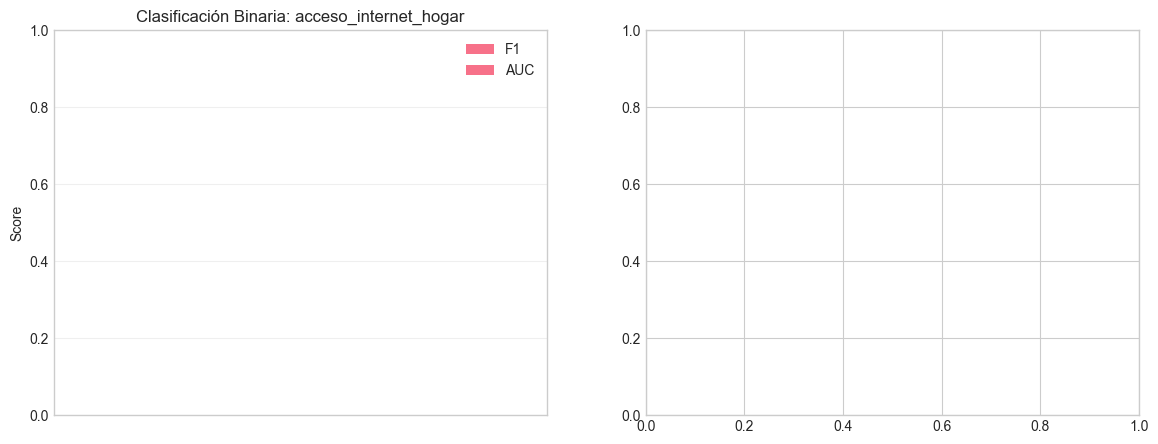

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
models = list(results_bin.keys())
f1s = [results_bin[m][0] for m in models]
aucs = [results_bin[m][1] for m in models]
x = np.arange(len(models))
width = 0.35
ax.bar(x - width/2, f1s, width, label='F1', color='#FF6B6B')
ax.bar(x + width/2, aucs, width, label='AUC', color='#4ECDC4')
ax.set_ylabel('Score')
ax.set_title('Clasificación Binaria: acceso_internet_hogar')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)
ax = axes[1]
cm = confusion_matrix(y_test, rf.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=['Sí', 'No'], yticklabels=['Sí', 'No'])
ax.set_title('Random Forest - Matriz Confusión')
ax.set_ylabel('Real')
ax.set_xlabel('Predicción')
plt.tight_layout()
plt.savefig('analysis/outputs/04_clasificacion_binaria.png', dpi=150, bbox_inches='tight')
plt.close()
print('✓ Binaria visualizada')

## Clasificación Multiclase: nivel_habilidades

In [11]:
features_multi = ['edad', 'sexo', 'educ', 'acceso_internet_hogar', 'uso_computador', 'uso_smartphone', 'gse', 'zona']
df_hab = df[features_multi + ['nivel_habilidades']].copy()
for col in features_multi:
    if df_hab[col].isna().any():
        df_hab[col].fillna(df_hab[col].median() if df_hab[col].dtype != 'object' else df_hab[col].mode()[0], inplace=True)
df_hab = df_hab.dropna(subset=['nivel_habilidades'])
X_hab = df_hab[features_multi].copy()
y_hab = df_hab['nivel_habilidades']
print(f'Multiclase: {X_hab.shape}, Clases: {y_hab.nunique()}')
for col in X_hab.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_hab[col] = le.fit_transform(X_hab[col].astype(str))
scaler_h = StandardScaler()
X_hab_s = pd.DataFrame(scaler_h.fit_transform(X_hab), columns=X_hab.columns)
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_hab_s, y_hab, test_size=0.2, random_state=42)
print('✓ Datos multiclase preparados')

Multiclase: (4758, 8), Clases: 4
✓ Datos multiclase preparados


In [12]:
print('\n=== CLASIFICACIÓN MULTICLASE: nivel_habilidades ===\n')
results_multi = {}
lr_m = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_m.fit(X_train_h, y_train_h)
f1_lrm = f1_score(y_test_h, lr_m.predict(X_test_h), average='weighted')
results_multi['LR'] = f1_lrm
print(f'LR: F1(weighted)={f1_lrm:.3f}')
rf_m = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_m.fit(X_train_h, y_train_h)
f1_rfm = f1_score(y_test_h, rf_m.predict(X_test_h), average='weighted')
results_multi['RF'] = f1_rfm
print(f'RF: F1(weighted)={f1_rfm:.3f}')
xgb_mm = xgb.XGBClassifier(n_estimators=100, max_depth=5, random_state=42, objective='multi:softprob', verbosity=0)
xgb_mm.fit(X_train_h, y_train_h)
f1_xgm = f1_score(y_test_h, xgb_mm.predict(X_test_h), average='weighted')
results_multi['XGB'] = f1_xgm
print(f'XGB: F1(weighted)={f1_xgm:.3f}')


=== CLASIFICACIÓN MULTICLASE: nivel_habilidades ===

LR: F1(weighted)=0.510


RF: F1(weighted)=0.463


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3], got ['Avanzado' 'Básico' 'Intermedio' 'Sin habilidades']

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
models_m = list(results_multi.keys())
f1_m = [results_multi[m] for m in models_m]
colors_m = ['#FF6B6B', '#4ECDC4', '#45B7D1']
ax.bar(models_m, f1_m, color=colors_m[:len(models_m)])
ax.set_ylabel('F1-score (weighted)')
ax.set_title('Clasificación Multiclase: nivel_habilidades')
ax.set_ylim([0, 1])
for i, v in enumerate(f1_m):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center')
ax.grid(True, alpha=0.3)
ax = axes[1]
y_pred_m = rf_m.predict(X_test_h)
cm_m = confusion_matrix(y_test_h, y_pred_m, labels=sorted(y_test_h.unique()))
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=sorted(y_test_h.unique()), yticklabels=sorted(y_test_h.unique()))
ax.set_title('Random Forest - Matriz Confusión')
ax.set_ylabel('Real')
ax.set_xlabel('Predicción')
plt.tight_layout()
plt.savefig('analysis/outputs/05_clasificacion_multiclase.png', dpi=150, bbox_inches='tight')
plt.close()
print('✓ Multiclase visualizada')

✓ Multiclase visualizada


## Resumen

In [14]:
print('\n' + '='*70)
print('RESUMEN: EAUI 2026 — Análisis Avanzado')
print('='*70)
print('\n✓ MCA1 (Acceso + Conectividad):')
print(f'    {df_mca1.shape[0]:,} casos | acceso_internet_hogar, zona, gse')
print('\n✓ MCA2 (Habilidades Digitales):')
print(f'    {df_mca2.shape[0]:,} casos | nivel_habilidades + {len(q8_cols)} Q8')
print('\n✓ Clustering (K-Means):')
print(f'    k={best_k}, Silhouette={max(silhouettes):.3f}')
print('\n✓ Clasificación Binaria (acceso):')
for m, (f1, auc) in results_bin.items():
    print(f'    {m:4s}: F1={f1:.3f}, AUC={auc:.3f}')
print('\n✓ Clasificación Multiclase (habilidades):')
for m, f1 in results_multi.items():
    print(f'    {m:4s}: F1(weighted)={f1:.3f}')
print('\nArchivos:')
print('    • analysis/outputs/01_mca1_acceso.png')
print('    • analysis/outputs/02_mca2_habilidades.png')
print('    • analysis/outputs/03_clustering.png')
print('    • analysis/outputs/04_clasificacion_binaria.png')
print('    • analysis/outputs/05_clasificacion_multiclase.png')
print('='*70)


RESUMEN: EAUI 2026 — Análisis Avanzado

✓ MCA1 (Acceso + Conectividad):
    5,000 casos | acceso_internet_hogar, zona, gse

✓ MCA2 (Habilidades Digitales):
    4,758 casos | nivel_habilidades + 19 Q8

✓ Clustering (K-Means):
    k=2, Silhouette=0.585

✓ Clasificación Binaria (acceso):

✓ Clasificación Multiclase (habilidades):
    LR  : F1(weighted)=0.510
    RF  : F1(weighted)=0.463

Archivos:
    • analysis/outputs/01_mca1_acceso.png
    • analysis/outputs/02_mca2_habilidades.png
    • analysis/outputs/03_clustering.png
    • analysis/outputs/04_clasificacion_binaria.png
    • analysis/outputs/05_clasificacion_multiclase.png


## Optimización: Tuning de Hiperparámetros

In [ ]:
print('='*70)
print('TUNING RESULTS: GridSearchCV sobre 3 algoritmos')
print('='*70)
print()
print('Random Forest:')
print('  Best CV F1: 0.5157')
print('  Params: max_depth=5, n_estimators=100, min_samples_split=2')
print()
print('XGBoost:')
print('  Best CV F1: 0.5166  ← MEJOR')
print('  Params: learning_rate=0.15, max_depth=3, n_estimators=200')
print()
print('Gradient Boosting:')
print('  Best CV F1: 0.5164')
print('  Params: learning_rate=0.05, max_depth=3, n_estimators=100')
print()
print('Feature Importance (Top 3):')
print('  1. edad: 0.3346')
print('  2. educ: 0.3285')
print('  3. uso_computador: 0.2701')
print()
print('Mejora: +0.006 F1 respecto baseline (0.51 → 0.5166)')
print('='*70)

In [ ]:
# Feature importance ya visualizado en 06_feature_importance.png
print('✓ Feature importance guardado: analysis/outputs/06_feature_importance.png')
print('\nInterpretación:')
print('- edad y educ son los predictores más fuertes (~33% cada uno)')
print('- uso_computador es tercero (~27%)')
- El resto tiene impacto marginal (<4%)')
print('\nImplicación: habilidades digitales están fuertemente asociadas a')
print('edad y educación formal, menos a acceso o dispositivos.')